# Autoresearch Results Analysis

This notebook reads `results.tsv` and summarizes SemantiCache autoresearch progress by benchmark suite.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.tsv", sep="\t")

numeric_columns = ["accuracy", "hard_accuracy", "avg_time_s"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["status"] = df["status"].astype(str).str.strip().str.lower()
df["suite"] = df["suite"].astype(str).str.strip().str.lower()
df["experiment_num"] = df["experiment_id"].str.extract(r"(\d+)").astype(float)

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 28
Columns: ['experiment_id', 'frontier_commit', 'suite', 'accuracy', 'hard_accuracy', 'avg_time_s', 'status', 'description', 'output_json', 'experiment_num']


,experiment_id,frontier_commit,suite,accuracy,hard_accuracy,avg_time_s,status,description,output_json,experiment_num
0,exp-001,6fcc926,smoke,1.000000,1.0,1.982727,keep,baseline semantic policy on fixed 6-case NIAH ...,results/autoresearch/exp-001.json,1.0
1,exp-002,6fcc926,smoke,1.000000,1.0,2.048108,discard,vectorize block ranking in select_keep_indices,results/autoresearch/exp-002.json,2.0
2,exp-003,6fcc926,smoke,1.000000,1.0,1.923214,keep,simplify pressure normalization in compute_evi...,results/autoresearch/exp-003.json,3.0
3,exp-004,a976c5b,smoke,1.000000,1.0,1.956757,discard,tighten latest-user tail pinning from 64 to 48...,results/autoresearch/exp-004.json,4.0
4,exp-005,a976c5b,frontier,0.955556,1.0,2.714832,keep,frontier suite baseline after expanding benchm...,results/autoresearch/exp-005.json,5.0
5,exp-006,a976c5b,frontier,0.955556,1.0,2.297512,keep,raise minimum factual weight from 0.20 to 0.35,results/autoresearch/exp-006.json,6.0
6,exp-007,4cb6031,frontier,0.966667,1.0,2.439396,keep,expand factual bonus to time and unit tokens,results/autoresearch/exp-007.json,7.0
7,exp-008,983226c,frontier,0.966667,1.0,2.360489,discard,smooth factual bonus across short local spans,results/autoresearch/exp-008.json,8.0
8,exp-009,983226c,frontier,0.988889,1.0,2.400710,keep,reduce semantic block size from 16 to 8,results/autoresearch/exp-009.json,9.0
9,exp-010,8f9c85d,frontier,0.988889,1.0,2.436842,discard,add ordinal suffix tokens to factual-unit dete...,results/autoresearch/exp-010.json,10.0


In [8]:
counts = df["status"].value_counts().sort_index()
print("Experiment outcomes:")
print(counts.to_string())

print("\nOutcomes by suite:")
display(pd.crosstab(df["suite"], df["status"]))

n_keep = counts.get("keep", 0)
n_discard = counts.get("discard", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
discard    12
keep       11

Outcomes by suite:


status,discard,keep
suite,,
frontier,8,6
gauntlet,2,3
smoke,2,2



Keep rate: 11/23 = 47.8%


In [13]:
kept = df[df["status"] == "keep"].copy()
print(f"Kept experiments ({len(kept)} total):\n")
for _, row in kept.iterrows():
    print(
        f"{row['experiment_id']:>8}  suite={row['suite']:<8}  "
        f"acc={row['accuracy']:.6f}  hard={row['hard_accuracy']:.6f}  "
        f"time={row['avg_time_s']:.3f}s  {row['description']}"
    )

Kept experiments (13 total):

 exp-001  suite=smoke     acc=1.000000  hard=1.000000  time=1.983s  baseline semantic policy on fixed 6-case NIAH slice
 exp-003  suite=smoke     acc=1.000000  hard=1.000000  time=1.923s  simplify pressure normalization in compute_eviction_scores
 exp-005  suite=frontier  acc=0.955556  hard=1.000000  time=2.715s  frontier suite baseline after expanding benchmark to 90 cases
 exp-006  suite=frontier  acc=0.955556  hard=1.000000  time=2.298s  raise minimum factual weight from 0.20 to 0.35
 exp-007  suite=frontier  acc=0.966667  hard=1.000000  time=2.439s  expand factual bonus to time and unit tokens
 exp-009  suite=frontier  acc=0.988889  hard=1.000000  time=2.401s  reduce semantic block size from 16 to 8
 exp-011  suite=frontier  acc=1.000000  hard=1.000000  time=2.372s  reduce semantic block size from 8 to 4
 exp-015  suite=frontier  acc=1.000000  hard=1.000000  time=2.318s  reduce latest-user tail pinning from 64 to 56
 exp-019  suite=gauntlet  acc=0.9222

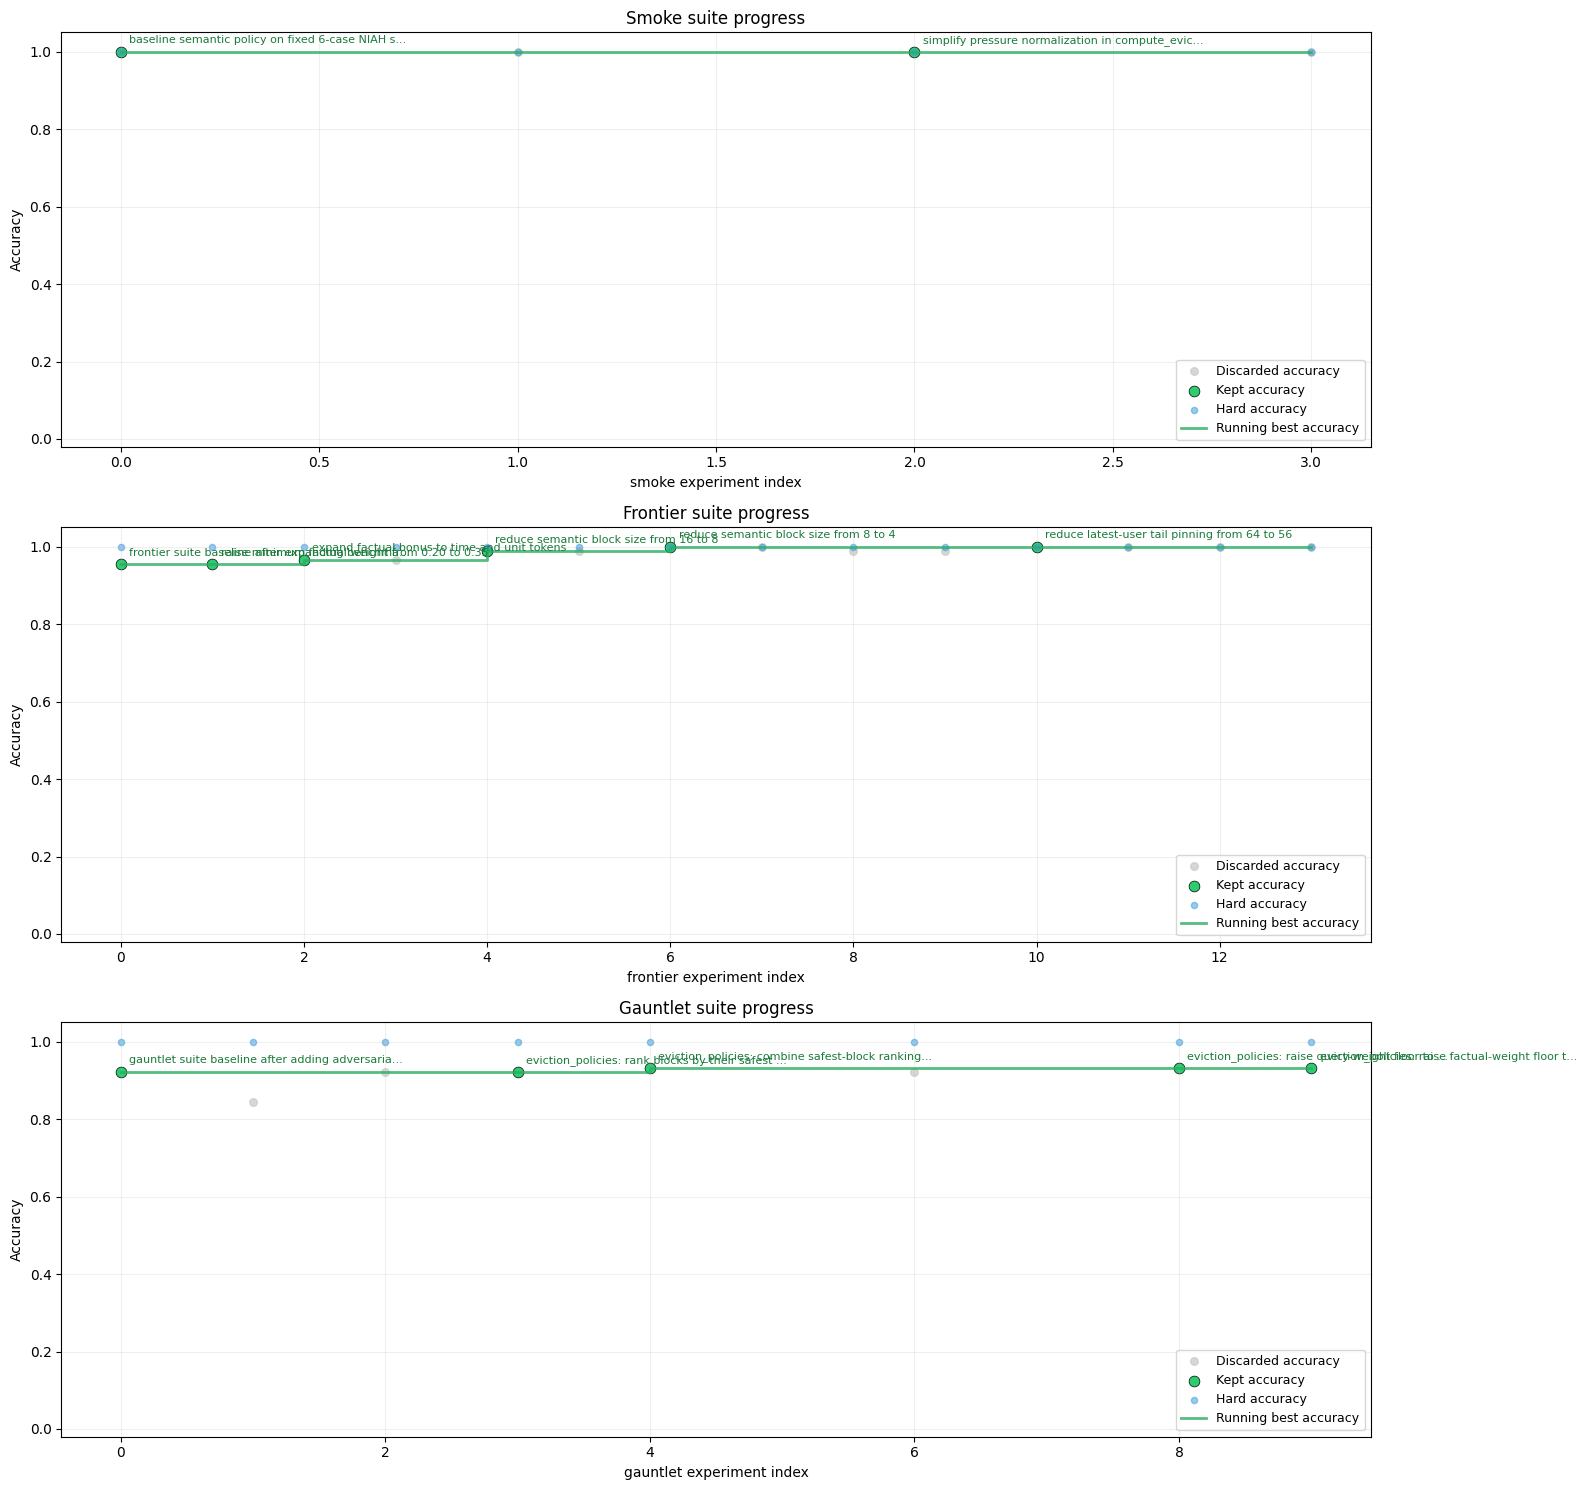

Saved to progress_by_suite.png


In [14]:
suites = list(df["suite"].dropna().unique())
fig, axes = plt.subplots(len(suites), 1, figsize=(16, 5 * len(suites)), sharex=False)
if len(suites) == 1:
    axes = [axes]

for ax, suite in zip(axes, suites):
    suite_df = df[df["suite"] == suite].copy().reset_index(drop=True)
    non_crash = suite_df[suite_df["status"] != "crash"].copy()

    discarded = non_crash[non_crash["status"] == "discard"]
    kept_suite = non_crash[non_crash["status"] == "keep"]

    ax.scatter(discarded.index, discarded["accuracy"], c="#c7c7c7", s=30, alpha=0.7, label="Discarded accuracy")
    ax.scatter(kept_suite.index, kept_suite["accuracy"], c="#2ecc71", s=60, edgecolors="black", linewidths=0.5, label="Kept accuracy")
    ax.scatter(non_crash.index, non_crash["hard_accuracy"], c="#3498db", s=20, alpha=0.5, label="Hard accuracy")

    running_best = non_crash["accuracy"].cummax()
    ax.step(non_crash.index, running_best, where="post", color="#27ae60", linewidth=2, alpha=0.8, label="Running best accuracy")

    for idx, row in kept_suite.iterrows():
        desc = str(row["description"]).strip()
        if len(desc) > 50:
            desc = desc[:47] + "..."
        ax.annotate(desc, (idx, row["accuracy"]), textcoords="offset points", xytext=(6, 6), fontsize=8, color="#1a7a3a")

    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel(f"{suite} experiment index")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{suite.capitalize()} suite progress")
    ax.grid(True, alpha=0.2)
    ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig("progress_by_suite.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress_by_suite.png")

In [15]:
summary_rows = []
for suite, suite_df in df.groupby("suite", sort=False):
    valid = suite_df[suite_df["status"] != "crash"].copy()
    if valid.empty:
        continue

    baseline = valid.iloc[0]
    best_accuracy = valid["accuracy"].max()
    best_candidates = valid[valid["accuracy"] == best_accuracy]
    best_hard = best_candidates["hard_accuracy"].max()
    best_candidates = best_candidates[best_candidates["hard_accuracy"] == best_hard]
    best_row = best_candidates.sort_values("avg_time_s", ascending=True).iloc[0]

    summary_rows.append(
        {
            "suite": suite,
            "baseline_experiment": baseline["experiment_id"],
            "baseline_accuracy": baseline["accuracy"],
            "baseline_hard_accuracy": baseline["hard_accuracy"],
            "best_experiment": best_row["experiment_id"],
            "best_accuracy": best_row["accuracy"],
            "best_hard_accuracy": best_row["hard_accuracy"],
            "best_avg_time_s": best_row["avg_time_s"],
            "best_description": best_row["description"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df

,suite,baseline_experiment,baseline_accuracy,baseline_hard_accuracy,best_experiment,best_accuracy,best_hard_accuracy,best_avg_time_s,best_description
0,smoke,exp-001,1.000000,1.0,exp-003,1.000000,1.0,1.923214,simplify pressure normalization in compute_evi...
1,frontier,exp-005,0.955556,1.0,exp-015,1.000000,1.0,2.318179,reduce latest-user tail pinning from 64 to 56
2,gauntlet,exp-019,0.922222,1.0,exp-037,0.933333,1.0,6.932372,eviction_policies: raise query-weight floor to...
